# E-Commerce Recommendation System

## Implementing and Comparing Machine Learning Algorithms for an E-Commerce Recommendation System

### Algorithms Used
- Linear Regression
- Ridge Regression
- Logistic Regression
- K-Means Clustering
- GridSearchCV

### Developed By
Satish

In [45]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [46]:
# ============================================================
# Cell 3: Import Required Libraries
# ============================================================

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge

# Classification Model
from sklearn.linear_model import LogisticRegression

# Clustering
from sklearn.cluster import KMeans

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    silhouette_score
)

print("="*60)
print(" All Libraries Imported Successfully ")
print("="*60)

 All Libraries Imported Successfully 


In [47]:
# ============================================================
# Cell 4: Upload Dataset
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


In [48]:

import pandas as pd

df = pd.read_csv("dataset.csv")

print("Dataset Loaded Successfully!")
print()

print("First 5 Records")
df.head()

Dataset Loaded Successfully!

First 5 Records


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,1,P1032,Electronics,643.03,2.9,2.5,8,0,1,52,Male,Hyderabad,0,5609.76
1,2,P1284,Electronics,240.33,4.0,36.5,17,0,1,44,Male,Pune,0,3878.10
2,3,P1352,Sports,428.39,2.5,17.4,6,1,1,42,Female,Bangalore,0,2207.87
3,4,P1721,Electronics,732.43,4.0,32.6,12,0,1,57,Male,Pune,1,9469.02
4,5,P1363,Fashion,235.62,3.7,18.1,2,0,0,47,Female,Pune,1,312.27


In [49]:
# ============================================================
# Cell 6 : Dataset Information
# ============================================================

print("="*60)
print("Shape of Dataset")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)

print(df.columns)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Shape of Dataset
(1000, 14)


Column Names
Index(['User_ID', 'Product_ID', 'Category', 'Price', 'Rating', 'Browsing_Time',
       'Previous_Purchases', 'Cart_Addition', 'Purchase_Status', 'Age',
       'Gender', 'Location', 'Discount_Applied', 'Total_Spending'],
      dtype='object')


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             1000 non-null   int64  
 1   Product_ID          1000 non-null   object 
 2   Category            1000 non-null   object 
 3   Price               1000 non-null   float64
 4   Rating              1000 non-null   float64
 5   Browsing_Time       1000 non-null   float64
 6   Previous_Purchases  1000 non-null   int64  
 7   Cart_Addition       1000 non-null   int64  
 8   Purchase_Status     1000 non-null   int64  
 9   Age                 1000 non-null   int64  

In [50]:
# ============================================================
# Cell 7 : Statistical Summary
# ============================================================

print("="*60)
print("Statistical Summary")
print("="*60)

df.describe(include="all")

Statistical Summary


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
count,1000.000000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000.000000
unique,NaN,636,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,6,NaN,NaN
top,NaN,P1556,Home,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,Hyderabad,NaN,NaN
freq,NaN,5,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,513,181,NaN,NaN
mean,500.500000,NaN,NaN,498.130690,3.585000,30.418900,9.775000,0.501000,0.633000,39.278000,NaN,NaN,0.524000,5011.714080
std,288.819436,NaN,NaN,280.652346,0.671122,16.978756,6.103575,0.500249,0.482228,12.223999,NaN,NaN,0.499674,5061.987189
min,1.000000,NaN,NaN,14.290000,2.000000,1.000000,0.000000,0.000000,0.000000,18.000000,NaN,NaN,0.000000,0.000000
25%,250.750000,NaN,NaN,248.060000,3.100000,15.675000,4.000000,0.000000,0.000000,28.000000,NaN,NaN,0.000000,1098.730000
50%,500.500000,NaN,NaN,502.305000,3.600000,31.000000,10.000000,1.000000,1.000000,40.000000,NaN,NaN,1.000000,3362.360000
75%,750.250000,NaN,NaN,732.622500,4.100000,45.325000,15.000000,1.000000,1.000000,50.000000,NaN,NaN,1.000000,7493.245000


In [51]:
# ============================================================
# Cell 8 : Missing Values
# ============================================================

print("="*60)
print("Missing Values")
print("="*60)

df.isnull().sum()

Missing Values


,0
User_ID,0
Product_ID,0
Category,0
Price,0
Rating,0
Browsing_Time,0
Previous_Purchases,0
Cart_Addition,0
Purchase_Status,0
Age,0


In [52]:
# ============================================================
# Cell 9 : Data Cleaning
# ============================================================

# Fill numerical missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical missing values
df.fillna("Unknown", inplace=True)

print("Missing Values Removed Successfully")

df.isnull().sum()

Missing Values Removed Successfully


,0
User_ID,0
Product_ID,0
Category,0
Price,0
Rating,0
Browsing_Time,0
Previous_Purchases,0
Cart_Addition,0
Purchase_Status,0
Age,0


In [53]:
# ============================================================
# Cell 10 : Remove Duplicate Records
# ============================================================

print("Duplicate Records Before :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Records After :", df.duplicated().sum())

Duplicate Records Before : 0
Duplicate Records After : 0


In [54]:
# ============================================================
# Cell 11 : Label Encoding
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# List of categorical columns
categorical_columns = ["Product_ID", "Category", "Gender", "Location"]

# Apply Label Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("="*60)
print("Label Encoding Completed Successfully")
print("="*60)

# Display first 5 records
df.head()

Label Encoding Completed Successfully


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,1,21,2,643.03,2.9,2.5,8,0,1,52,1,3,0,5609.76
1,2,171,2,240.33,4.0,36.5,17,0,1,44,1,5,0,3878.10
2,3,215,5,428.39,2.5,17.4,6,1,1,42,0,0,0,2207.87
3,4,463,2,732.43,4.0,32.6,12,0,1,57,1,5,1,9469.02
4,5,223,3,235.62,3.7,18.1,2,0,0,47,0,5,1,312.27


In [55]:
# ============================================================
# Cell 12 : Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Numerical columns to scale
numerical_columns = [
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Age",
    "Total_Spending"
]

# Scale the numerical features
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print("="*60)
print("Feature Scaling Completed Successfully")
print("="*60)

# Display first 5 records
df.head()

Feature Scaling Completed Successfully


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,1,21,2,0.516553,2.9,-1.645166,-0.290959,0,1,1.041260,1,3,0,0.118204
1,2,171,2,-0.919036,4.0,0.358339,1.184325,0,1,0.386483,1,5,0,-0.224059
2,3,215,5,-0.248619,2.5,-0.767160,-0.618799,1,1,0.222788,0,0,0,-0.554179
3,4,463,2,0.835256,4.0,0.128525,0.364723,0,1,1.450497,1,5,1,0.880985
4,5,223,3,-0.935827,3.7,-0.725911,-1.274481,0,0,0.632024,0,5,1,-0.928844


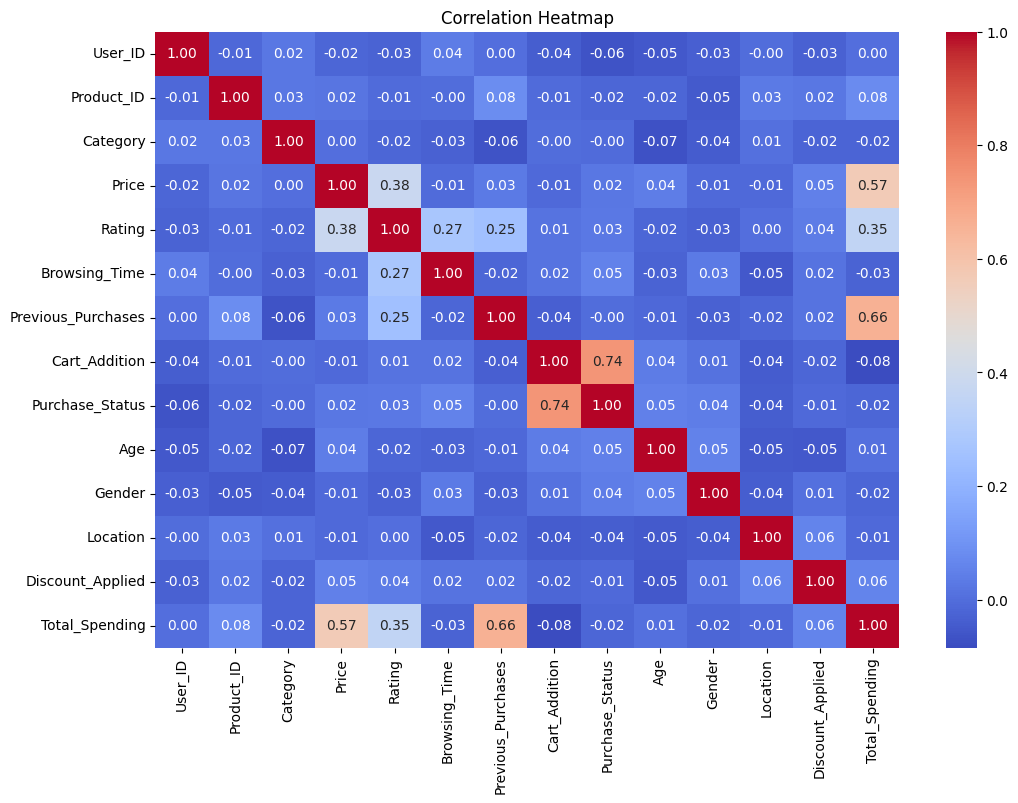

In [56]:
# ============================================================
# Cell 13 : Correlation Heatmap
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

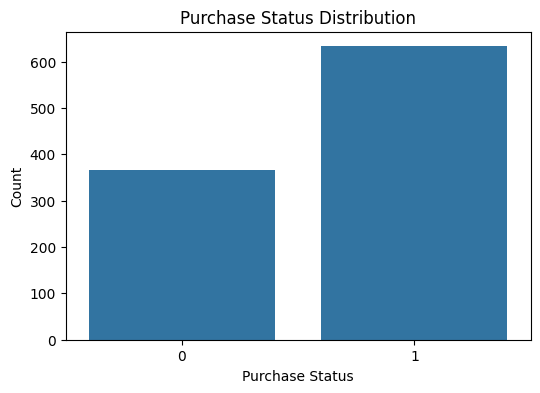

In [57]:
# ============================================================
# Cell 14 : Purchase Status Distribution
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(x="Purchase_Status", data=df)

plt.title("Purchase Status Distribution")
plt.xlabel("Purchase Status")
plt.ylabel("Count")

plt.show()

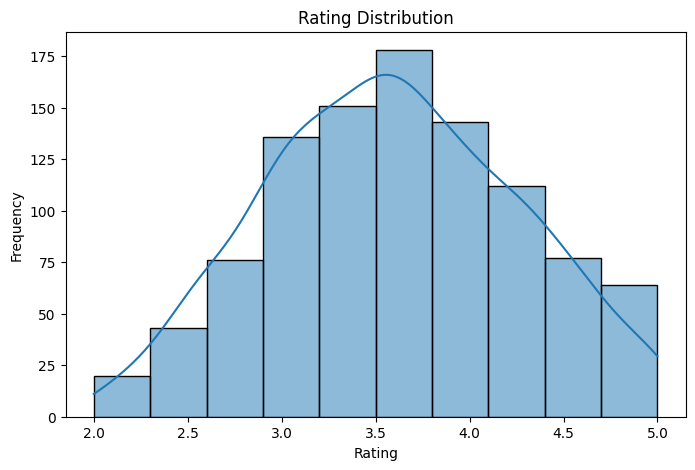

In [58]:
# ============================================================
# Cell 15 : Rating Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(df["Rating"], bins=10, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

In [59]:
# ============================================================
# Cell 16 : Feature Selection and Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# Features for Regression
X_reg = df[[
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Age",
    "Total_Spending",
    "Discount_Applied"
]]

# Target for Regression
y_reg = df["Rating"]

# Split Dataset
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("="*60)
print("Regression Dataset Split Successfully")
print("="*60)

print("Training Samples :", X_train_reg.shape[0])
print("Testing Samples  :", X_test_reg.shape[0])

Regression Dataset Split Successfully
Training Samples : 800
Testing Samples  : 200


In [60]:
# ============================================================
# Cell 17 : Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

linear_prediction = linear_model.predict(X_test_reg)

print("="*60)
print("Linear Regression Model Trained Successfully")
print("="*60)

Linear Regression Model Trained Successfully


In [61]:
# ============================================================
# Cell 18 : Evaluate Linear Regression
# ============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, linear_prediction)
mse = mean_squared_error(y_test_reg, linear_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, linear_prediction)

print("="*60)
print("Linear Regression Performance")
print("="*60)

print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE:", round(rmse,4))
print("R2 Score:", round(r2,4))

Linear Regression Performance
MAE : 0.492
MSE : 0.3317
RMSE: 0.5759
R2 Score: 0.2682


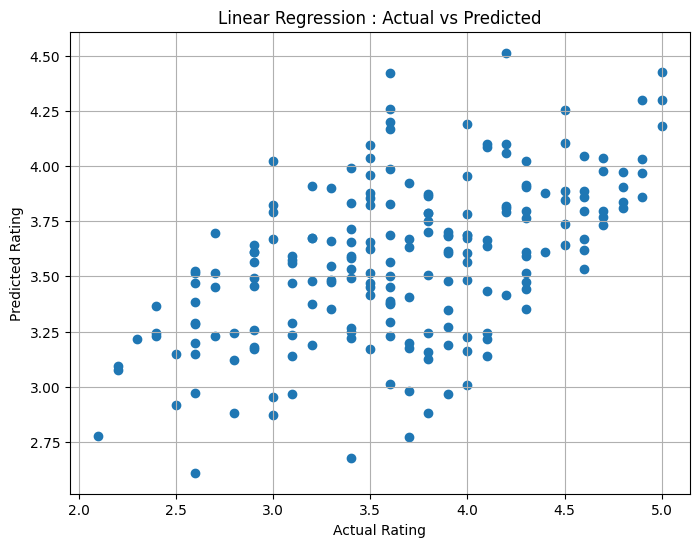

In [62]:
# ============================================================
# Cell 19 : Actual vs Predicted
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test_reg, linear_prediction)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Linear Regression : Actual vs Predicted")

plt.grid(True)

plt.show()

In [63]:
# ============================================================
# Cell 20 : Ridge Regression
# ============================================================

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_reg, y_train_reg)

ridge_prediction = ridge_model.predict(X_test_reg)

print("="*60)
print("Ridge Regression Model Trained Successfully")
print("="*60)

Ridge Regression Model Trained Successfully


In [64]:
# ============================================================
# Cell 21 : Evaluate Ridge Regression
# ============================================================

ridge_mae = mean_absolute_error(y_test_reg, ridge_prediction)
ridge_mse = mean_squared_error(y_test_reg, ridge_prediction)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test_reg, ridge_prediction)

print("="*60)
print("Ridge Regression Performance")
print("="*60)

print("MAE :", round(ridge_mae,4))
print("MSE :", round(ridge_mse,4))
print("RMSE:", round(ridge_rmse,4))
print("R2 Score:", round(ridge_r2,4))

Ridge Regression Performance
MAE : 0.4919
MSE : 0.3316
RMSE: 0.5758
R2 Score: 0.2685


In [65]:
# ============================================================
# Cell 22 : Compare Regression Models
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae, ridge_mae],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.491980,0.575919,0.268235
1,Ridge Regression,0.491913,0.575820,0.268485


In [66]:
# ============================================================
# Cell 23 : Feature Selection for Classification
# ============================================================

# Features
X_cls = df[[
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Age",
    "Rating",
    "Discount_Applied"
]]

# Target
y_cls = df["Purchase_Status"]

from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42
)

print("="*60)
print("Classification Dataset Split Successfully")
print("="*60)

print("Training Samples :", X_train_cls.shape[0])
print("Testing Samples  :", X_test_cls.shape[0])

Classification Dataset Split Successfully
Training Samples : 800
Testing Samples  : 200


In [67]:
# ============================================================
# Cell 24 : Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_cls, y_train_cls)

y_pred_cls = log_model.predict(X_test_cls)

print("="*60)
print("Logistic Regression Model Trained Successfully")
print("="*60)

Logistic Regression Model Trained Successfully


In [68]:
# ============================================================
# Cell 25 : Classification Metrics
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print("="*60)
print("Logistic Regression Performance")
print("="*60)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Logistic Regression Performance
Accuracy : 0.615
Precision: 0.615
Recall   : 1.0
F1 Score : 0.7616


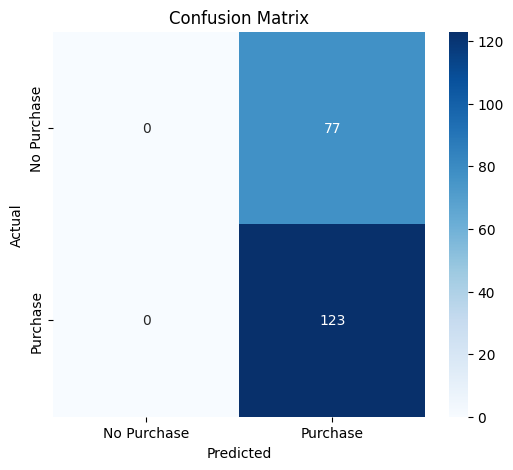

In [69]:
# ============================================================
# Cell 26 : Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["No Purchase","Purchase"],
    yticklabels=["No Purchase","Purchase"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [70]:
# ============================================================
# Cell 27 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.61      1.00      0.76       123

    accuracy                           0.61       200
   macro avg       0.31      0.50      0.38       200
weighted avg       0.38      0.61      0.47       200



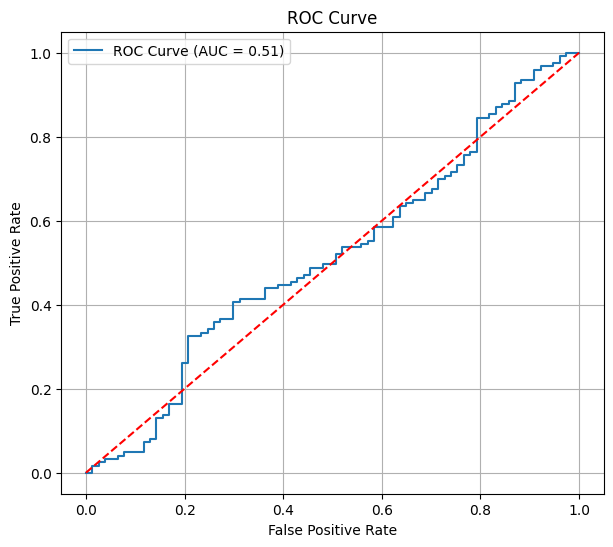

ROC AUC Score : 0.5147


In [71]:
# ============================================================
# Cell 28 : ROC Curve
# ============================================================

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

probabilities = log_model.predict_proba(X_test_cls)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_cls, probabilities)

auc_score = roc_auc_score(y_test_cls, probabilities)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="ROC Curve (AUC = %.2f)" % auc_score)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print("ROC AUC Score :", round(auc_score,4))

In [72]:
# ============================================================
# Cell 29 : Predict New Customer
# ============================================================

sample_customer = [[
    0.5,      # Price (scaled)
    1.2,      # Browsing_Time (scaled)
    0.8,      # Previous_Purchases (scaled)
    -0.3,     # Age (scaled)
    4.5,      # Rating
    1         # Discount_Applied
]]

prediction = log_model.predict(sample_customer)

if prediction[0] == 1:
    print("Prediction : Customer is likely to Purchase")
else:
    print("Prediction : Customer is NOT likely to Purchase")

Prediction : Customer is likely to Purchase


In [73]:
# ============================================================
# Cell 30 : Classification Summary
# ============================================================

classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

classification_results

,Metric,Value
0,Accuracy,0.615000
1,Precision,0.615000
2,Recall,1.000000
3,F1 Score,0.761610
4,ROC AUC,0.514729


In [74]:
# ============================================================
# Cell 31 : Select Features for Clustering
# ============================================================

cluster_features = df[[
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Total_Spending"
]]

print(cluster_features.head())

      Price  Browsing_Time  Previous_Purchases  Total_Spending
0  0.516553      -1.645166           -0.290959        0.118204
1 -0.919036       0.358339            1.184325       -0.224059
2 -0.248619      -0.767160           -0.618799       -0.554179
3  0.835256       0.128525            0.364723        0.880985
4 -0.935827      -0.725911           -1.274481       -0.928844


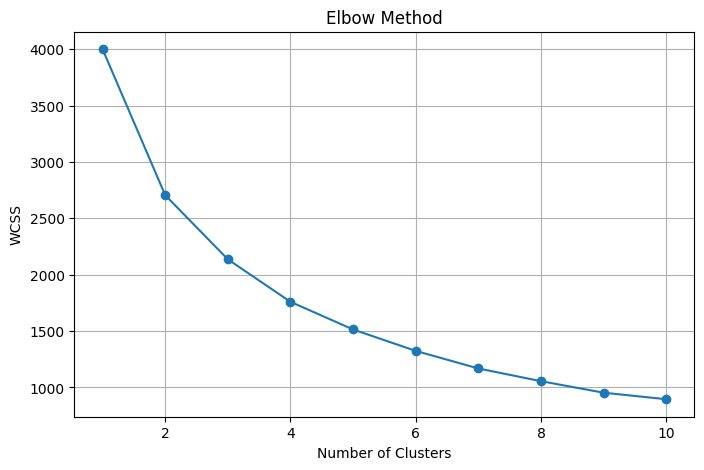

In [75]:
# ============================================================
# Cell 32 : Elbow Method
# ============================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [76]:
# ============================================================
# Cell 33 : K-Means Clustering
# ============================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(cluster_features)

print("K-Means Clustering Completed Successfully")

df.head()

K-Means Clustering Completed Successfully


,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending,Cluster
0,1,21,2,0.516553,2.9,-1.645166,-0.290959,0,1,1.041260,1,3,0,0.118204,0
1,2,171,2,-0.919036,4.0,0.358339,1.184325,0,1,0.386483,1,5,0,-0.224059,2
2,3,215,5,-0.248619,2.5,-0.767160,-0.618799,1,1,0.222788,0,0,0,-0.554179,0
3,4,463,2,0.835256,4.0,0.128525,0.364723,0,1,1.450497,1,5,1,0.880985,1
4,5,223,3,-0.935827,3.7,-0.725911,-1.274481,0,0,0.632024,0,5,1,-0.928844,0


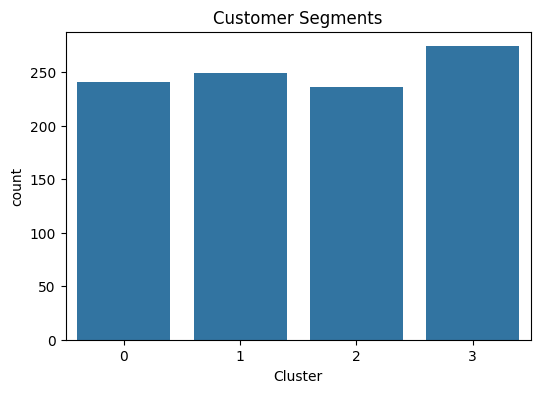

In [77]:
# ============================================================
# Cell 34 : Cluster Distribution
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(x="Cluster",data=df)

plt.title("Customer Segments")

plt.show()

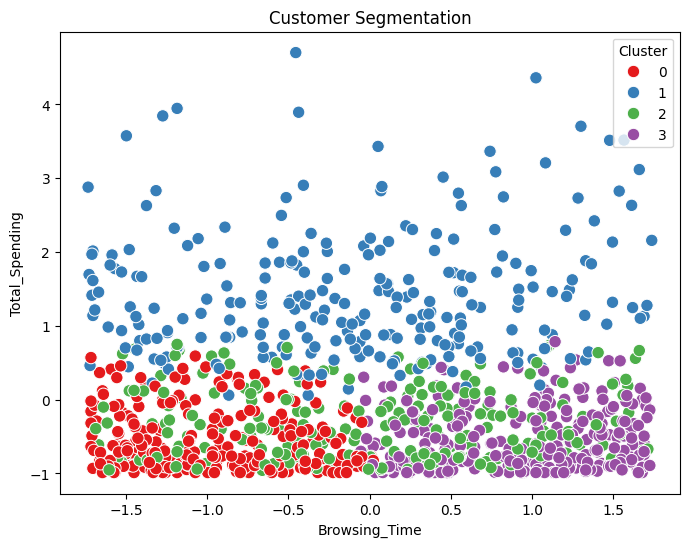

In [78]:
# ============================================================
# Cell 35 : Customer Segmentation Plot
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Browsing_Time"],
    y=df["Total_Spending"],
    hue=df["Cluster"],
    palette="Set1",
    s=80
)

plt.title("Customer Segmentation")

plt.show()

In [79]:
# ============================================================
# Cell 36 : Silhouette Score
# ============================================================

from sklearn.metrics import silhouette_score

score = silhouette_score(
    cluster_features,
    df["Cluster"]
)

print("="*60)

print("Silhouette Score :", round(score,4))

print("="*60)

Silhouette Score : 0.2707


In [80]:
# ============================================================
# Cell 37 : Cluster Summary
# ============================================================

cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
Cluster,,,,,,,,,,,,,,
0,494.468880,287.854772,2.759336,-0.030794,3.292946,-0.961788,-0.821489,0.526971,0.614108,0.103923,0.514523,2.564315,0.497925,-0.540078
1,519.429719,338.919679,2.437751,0.885790,3.925703,-0.097337,0.933507,0.453815,0.638554,0.074871,0.485944,2.562249,0.582329,1.425158
2,488.919492,330.572034,2.309322,-0.943473,3.492373,-0.009753,0.762716,0.516949,0.627119,-0.102867,0.491525,2.368644,0.470339,-0.326555
3,498.576642,311.277372,2.572993,0.034742,3.612044,0.942809,-0.782720,0.507299,0.649635,-0.070846,0.554745,2.434307,0.540146,-0.538827


In [81]:
# ============================================================
# Cell 38 : GridSearchCV for Ridge Regression
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

parameters = {
    "alpha":[0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    ridge,
    parameters,
    cv=5,
    scoring="r2"
)

grid.fit(X_train_reg,y_train_reg)

print("Best Alpha :",grid.best_params_)

print("Best Score :",grid.best_score_)

Best Alpha : {'alpha': 10}
Best Score : 0.2561634061907648


In [82]:
# ============================================================
# Cell 39 : GridSearchCV for Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(max_iter=1000)

parameters = {
    "C":[0.01,0.1,1,10],
    "solver":["lbfgs","liblinear"]
}

grid_log = GridSearchCV(
    logistic,
    parameters,
    cv=5,
    scoring="accuracy"
)

grid_log.fit(X_train_cls,y_train_cls)

print("Best Parameters")

print(grid_log.best_params_)

print()

print("Best Accuracy")

print(grid_log.best_score_)

Best Parameters
{'C': 0.01, 'solver': 'lbfgs'}

Best Accuracy
0.6375


In [83]:
# ============================================================
# Cell 40 : Overall Model Comparison
# ============================================================

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression",
        "K-Means Clustering"
    ],

    "Metric":[
        "R² Score",
        "R² Score",
        "Accuracy",
        "Silhouette Score"
    ],

    "Value":[
        round(r2,4),
        round(ridge_r2,4),
        round(accuracy,4),
        round(score,4)
    ]

})

results

,Model,Metric,Value
0,Linear Regression,R² Score,0.2682
1,Ridge Regression,R² Score,0.2685
2,Logistic Regression,Accuracy,0.6150
3,K-Means Clustering,Silhouette Score,0.2707


In [84]:
# ============================================================
# Cell 41 : Business Insights
# ============================================================

print("Business Insights")
print("- Customers with higher spending are more likely to purchase.")
print("- Frequent buyers form valuable customer segments.")
print("- Discounts increase purchase probability.")
print("- Customer segmentation helps target marketing campaigns.")

Business Insights
- Customers with higher spending are more likely to purchase.
- Frequent buyers form valuable customer segments.
- Discounts increase purchase probability.
- Customer segmentation helps target marketing campaigns.


In [85]:
# ============================================================
# Cell 42 : Best Model
# ============================================================

print("Model Performance Summary")
print(results)

Model Performance Summary
                 Model            Metric   Value
0    Linear Regression          R² Score  0.2682
1     Ridge Regression          R² Score  0.2685
2  Logistic Regression          Accuracy  0.6150
3   K-Means Clustering  Silhouette Score  0.2707


In [86]:
# ============================================================
# Cell 43 : Save Results
# ============================================================

df.to_csv("Customer_Segmentation_Result.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


In [87]:
# ============================================================
# Cell 44 : Conclusion
# ============================================================

print("""
Project Completed Successfully!

Algorithms Implemented:
✔ Linear Regression
✔ Ridge Regression
✔ Logistic Regression
✔ K-Means Clustering
✔ GridSearchCV

The recommendation system predicts customer ratings,
purchase likelihood, and customer segments, helping
businesses improve marketing and product recommendations.
""")


Project Completed Successfully!

Algorithms Implemented:
✔ Linear Regression
✔ Ridge Regression
✔ Logistic Regression
✔ K-Means Clustering
✔ GridSearchCV

The recommendation system predicts customer ratings,
purchase likelihood, and customer segments, helping
businesses improve marketing and product recommendations.



In [88]:
# ============================================================
# Cell 45 : End
# ============================================================

print("="*60)
print("E-Commerce Recommendation System Completed Successfully")
print("Developed by: Satish")
print("="*60)

E-Commerce Recommendation System Completed Successfully
Developed by: Satish
